# Validation of mean velocity values

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define datasets to compare

In [2]:
augmenterra_data_dir = Path("/home/lukas/projects/ADUCAT/data/Augmenterra/processed")
own_insar_data_dir = Path("/home/lukas/projects/ADUCAT/data/final_outputs")


print("Reference data directory:", augmenterra_data_dir)
print("Directly of own processed data:", own_insar_data_dir)


Reference data directory: /home/lukas/projects/ADUCAT/data/Augmenterra/processed
Directly of own processed data: /home/lukas/projects/ADUCAT/data/final_outputs


In [3]:
orbit_direction = "ASC"

ref_augmenterra_file = Path(augmenterra_data_dir, f"VIENNA_TUNNELLING_velocity_{orbit_direction}_without_timeseries.parquet")
print("Augmenterra reference data file:", ref_augmenterra_file)

processed_data_file = Path(own_insar_data_dir, "TS_Mintpy_stack_S1_073_ASC_20220101_20241228_c2_z3_r9_f0.5.parquet")
print("Own processed data file:", processed_data_file)

Augmenterra reference data file: /home/lukas/projects/ADUCAT/data/Augmenterra/processed/VIENNA_TUNNELLING_velocity_ASC_without_timeseries.parquet
Own processed data file: /home/lukas/projects/ADUCAT/data/final_outputs/TS_Mintpy_stack_S1_073_ASC_20220101_20241228_c2_z3_r9_f0.5.parquet


## Statistics of the two data sets

### Augmenterra data

In [4]:
# ============================================================
# 1. Inspect column names
# ============================================================

print("\n" + "=" * 70)
print("AUGMENTERRA DATASET")
print("=" * 70)

augmenterra_columns = pd.read_parquet(
    ref_augmenterra_file,
    engine="pyarrow"
).columns.tolist()

for i, col in enumerate(augmenterra_columns):
    print(f"{i:3d}: {col}")


AUGMENTERRA DATASET
  0: CODE
  1: HEIGHT
  2: H_STDEV
  3: VEL
  4: V_STDEV
  5: ACC
  6: A_STDEV
  7: SEASON_AMP
  8: S_AMP_STD
  9: SEASON_PHS
 10: S_PHS_STD
 11: COHERENCE
 12: STD_DEF
 13: EFF_AREA
 14: INC_ANG
 15: geometry
 16: VEL_20220101_20241231
 17: V_STDERR_20220101_20241231
 18: VEL_20200101_20241231
 19: V_STDERR_20200101_20241231
 20: VEL_20190101_20260430
 21: V_STDERR_20190101_20260430


In [5]:
# ============================================================
# Columns to load
# ============================================================

AUGMENTERRA_VELOCITY_COL = "VEL_20220101_20241231"
AUGMENTERRA_COHERENCE_COL = "COHERENCE"

augmenterra_cols = [
    AUGMENTERRA_VELOCITY_COL,
    AUGMENTERRA_COHERENCE_COL,
]

In [6]:
augmenterra = pd.read_parquet(
    ref_augmenterra_file,
    columns=augmenterra_cols,
    engine="pyarrow"
)

In [7]:
print("\nLoaded data:")
print(f"Augmenterra: {len(augmenterra):,} points")


Loaded data:
Augmenterra: 2,924,926 points


In [8]:
# ============================================================
# Basic statistics
# ============================================================

print("\n" + "=" * 70)
print("AUGMENTERRA VELOCITY STATISTICS")
print("=" * 70)

print(
    augmenterra[AUGMENTERRA_VELOCITY_COL]
    .describe()
)


AUGMENTERRA VELOCITY STATISTICS
count    2.924926e+06
mean    -3.382984e-01
std      1.754409e+00
min     -2.530000e+01
25%     -1.000000e+00
50%     -2.000000e-01
75%      5.000000e-01
max      1.410000e+01
Name: VEL_20220101_20241231, dtype: float64


In [9]:
print("\n" + "=" * 70)
print("AUGMENTERRA COHERENCE STATISTICS")
print("=" * 70)

print(
    augmenterra[AUGMENTERRA_COHERENCE_COL]
    .describe()
)


AUGMENTERRA COHERENCE STATISTICS
count    2.924926e+06
mean     5.852312e-01
std      2.138453e-01
min      1.500000e-01
25%      4.000000e-01
50%      5.700000e-01
75%      7.700000e-01
max      1.000000e+00
Name: COHERENCE, dtype: float64


### Own dataset

In [10]:
print("\n" + "=" * 70)
print("OWN INSAR DATASET")
print("=" * 70)

own_columns = pd.read_parquet(
    processed_data_file,
    engine="pyarrow"
).columns.tolist()

for i, col in enumerate(own_columns):
    print(f"{i:3d}: {col}")


OWN INSAR DATASET
  0: CODE
  1: HEIGHT
  2: H_STDEV
  3: VEL
  4: V_STDEV
  5: COHERENCE
  6: EFF_AREA
  7: D20220101
  8: D20220113
  9: D20220125
 10: D20220206
 11: D20220218
 12: D20220302
 13: D20220314
 14: D20220326
 15: D20220407
 16: D20220419
 17: D20220501
 18: D20220513
 19: D20220525
 20: D20220606
 21: D20220618
 22: D20220630
 23: D20220712
 24: D20220724
 25: D20220805
 26: D20220817
 27: D20220829
 28: D20220910
 29: D20220922
 30: D20221004
 31: D20221016
 32: D20221028
 33: D20221109
 34: D20221121
 35: D20221203
 36: D20221215
 37: D20221227
 38: D20230108
 39: D20230120
 40: D20230201
 41: D20230213
 42: D20230225
 43: D20230309
 44: D20230321
 45: D20230402
 46: D20230414
 47: D20230426
 48: D20230508
 49: D20230520
 50: D20230601
 51: D20230613
 52: D20230625
 53: D20230707
 54: D20230719
 55: D20230731
 56: D20230812
 57: D20230824
 58: D20230905
 59: D20230917
 60: D20230929
 61: D20231011
 62: D20231023
 63: D20231104
 64: D20231116
 65: D20231128
 66: D2023

In [11]:
# ============================================================
# Columns to load
# ============================================================

OWN_VELOCITY_COL = "VEL"
OWN_COHERENCE_COL = "COHERENCE"

own_cols = [
    OWN_VELOCITY_COL,
    OWN_COHERENCE_COL,
]

In [12]:
own = pd.read_parquet(
    processed_data_file,
    columns=own_cols,
    engine="pyarrow"
)

In [13]:
print("\nLoaded data:")
print(f"Own SBAS:    {len(own):,} points")


Loaded data:
Own SBAS:    475,161 points


In [14]:
# ============================================================
# Basic statistics
# ============================================================


print("\n" + "=" * 70)
print("OWN SBAS VELOCITY STATISTICS")
print("=" * 70)

print(
    own[OWN_VELOCITY_COL]
    .describe()
)


OWN SBAS VELOCITY STATISTICS
count    475161.000000
mean         -0.647376
std           6.362406
min         -55.517957
25%          -2.562667
50%          -0.048338
75%           2.640778
max          39.516676
Name: VEL, dtype: float64


In [15]:
print("\n" + "=" * 70)
print("OWN SBAS COHERENCE STATISTICS")
print("=" * 70)

print(
    own[OWN_COHERENCE_COL]
    .describe()
)


OWN SBAS COHERENCE STATISTICS
count    475161.000000
mean          0.944709
std           0.061095
min           0.800004
25%           0.898012
50%           0.976554
75%           0.995724
max           1.000000
Name: COHERENCE, dtype: float64


## Comparison

### velocity histograms

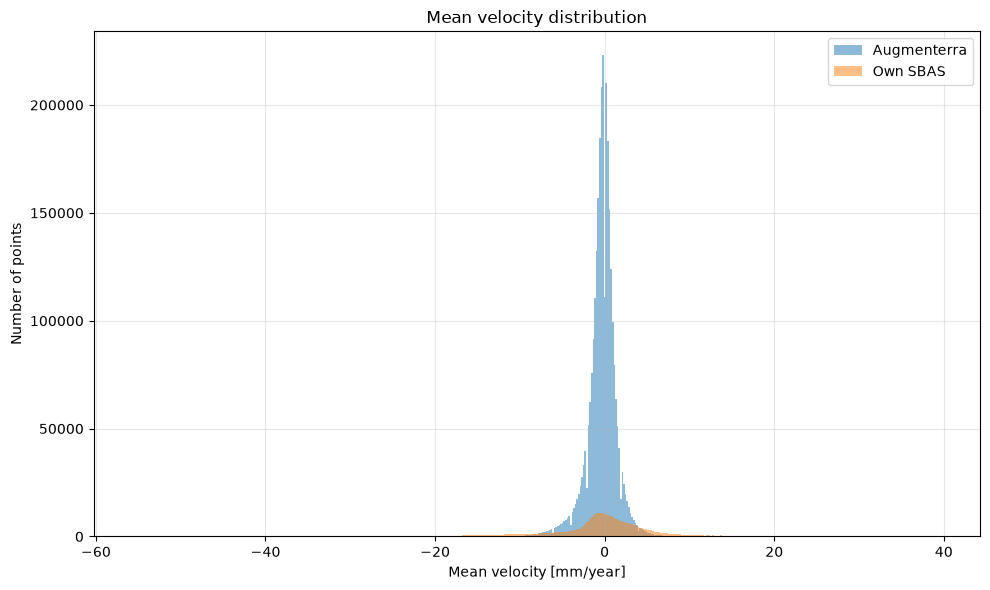

In [16]:
velocity_all = pd.concat([
    augmenterra[AUGMENTERRA_VELOCITY_COL],
    own[OWN_VELOCITY_COL]
]).dropna()

# Use common range
v_min = velocity_all.min()
v_max = velocity_all.max()

bins = np.linspace(v_min, v_max, 500)


plt.figure(figsize=(10, 6))

plt.hist(
    augmenterra[AUGMENTERRA_VELOCITY_COL].dropna(),
    bins=bins,
    alpha=0.5,
    label="Augmenterra",
)

plt.hist(
    own[OWN_VELOCITY_COL].dropna(),
    bins=bins,
    alpha=0.5,
    label="Own SBAS",
)

plt.xlabel("Mean velocity [mm/year]")
plt.ylabel("Number of points")
plt.title("Mean velocity distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

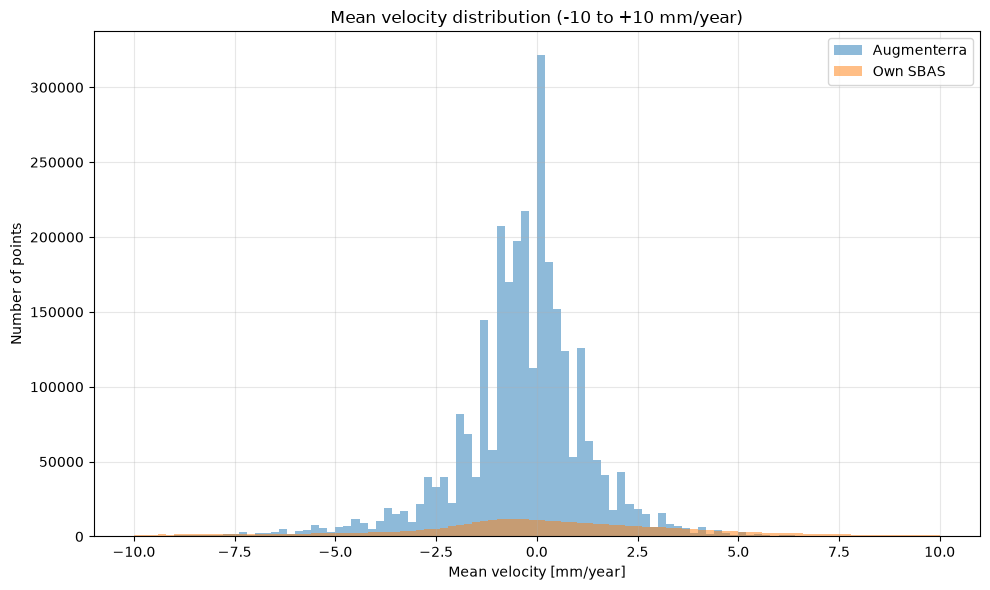

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    augmenterra[AUGMENTERRA_VELOCITY_COL].dropna(),
    bins=100,
    range=(-10, 10),
    alpha=0.5,
    label="Augmenterra",
)

plt.hist(
    own[OWN_VELOCITY_COL].dropna(),
    bins=100,
    range=(-10, 10),
    alpha=0.5,
    label="Own SBAS",
)

plt.xlabel("Mean velocity [mm/year]")
plt.ylabel("Number of points")
plt.title("Mean velocity distribution (-10 to +10 mm/year)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()